Extracting spectral graph embeddings...
Running K-Means on Spectral Embeddings for Elbow Curve...
Generating final segmented matrix using K=100...


c:\anaconda\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:453: UserWarning: Exited at iteration 65 with accuracies 
[1.59186231e-13 6.03883664e-08 7.61123187e-08 1.02304591e-07
 1.84950601e-07 3.89331431e-07 2.67035294e-07 6.57640856e-07
 6.44778939e-07 7.17621832e-07 8.38463566e-07 1.24476029e-06
 1.25852802e-06 1.98955752e-06 2.30068603e-06 3.34313882e-06
 5.11099693e-06 5.17912887e-06 4.89934467e-06 6.48706765e-06
 5.53907960e-07 9.11684674e-07 1.03180472e-06 1.59686657e-06
 1.59728980e-06 2.38811327e-06 2.55067579e-06 3.07343339e-06
 3.92079170e-06 5.11942343e-06 5.29648893e-06 7.91280012e-06
 1.44302660e-06 1.59044472e-06 1.62385157e-06 3.37361078e-06
 2.71308075e-06 4.02621688e-06 4.52996462e-06 6.39094437e-06
 2.84047764e-06 3.57950763e-06 6.80863604e-06 6.90522757e-06
 1.13374387e-05 1.16937506e-05 5.25353785e-06 1.21921393e-05
 5.62372379e-06 9.13934274e-06 5.87002781e-06 7.54495644e-06
 9.12900193e-06 9.92959985e-06 1.20644251e-05 9.61321181e-06
 8.09800024e-06 8.

Rendering separate plot windows...


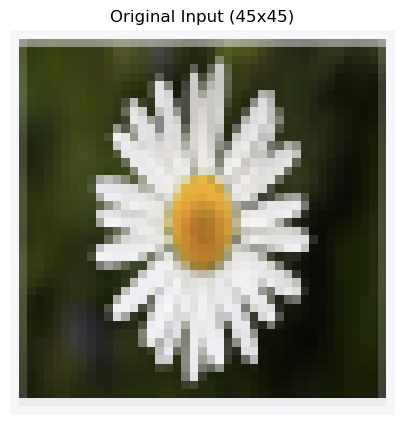

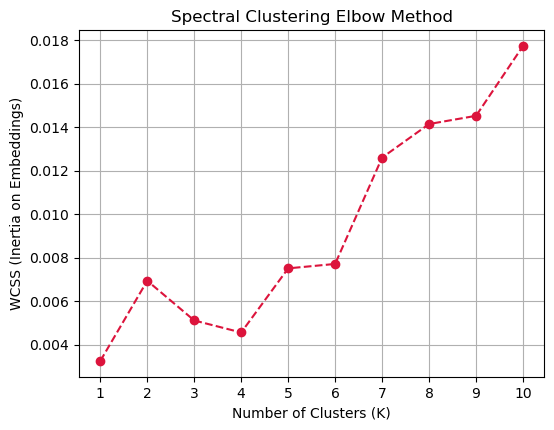

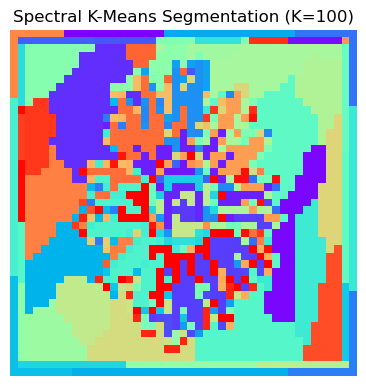

In [11]:
import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.manifold import SpectralEmbedding
from sklearn.preprocessing import minmax_scale

# ==========================================
# 1. LOAD AND PREPROCESS IMAGE (Using CV2)
# ==========================================
# Load image using matplotlib (Directly reads into standard RGB format)
orig_image = mpimg.imread("image.jpeg")

# Downsample image aggressively using OpenCV to protect system memory
# Spectral clustering builds an NxN matrix. A 45x45 grid = 2,025 x 2,025 matrix.
target_grid = (45, 45)
small_image = cv2.resize(orig_image, target_grid, interpolation=cv2.INTER_AREA)
height, width, channels = small_image.shape

# ==========================================
# 2. EXTRACT SPATIAL-COLOR FEATURE VECTOR [R, G, B, X, Y]
# ==========================================
# 1. Flatten and scale RGB color features between 0.0 and 1.0
flat_colors = small_image.reshape((-1, 3))
scaled_colors = minmax_scale(flat_colors)

# 2. Build and scale spatial 2D grid coordinates (X, Y)
x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
flat_coords = np.column_stack((x_coords.ravel(), y_coords.ravel()))
scaled_coords = minmax_scale(flat_coords)

# 3. Stack features into a 5D matrix [R, G, B, X, Y]
# Multiply spatial indices to balance distance vs. color importance
spatial_importance = 0.4
combined_features = np.hstack(
    (scaled_colors, scaled_coords * spatial_importance)
)

# ==========================================
# 3. GENERATE SPECTRAL EMBEDDINGS FOR ELBOW
# ==========================================
print("Extracting spectral graph embeddings...")

# We set n_components=10 so we have enough feature columns to test K values up to 10
embedding_model = SpectralEmbedding(
    n_components=10, affinity="rbf", gamma=15.0, random_state=42
)

# This extracts the low-dimensional eigenvectors from your 5D array
embeddings = embedding_model.fit_transform(combined_features)

# ==========================================
# 4. CALCULATE WCSS FOR THE ELBOW GRAPH
# ==========================================
wcss = []
k_range = range(1, 11)

print("Running K-Means on Spectral Embeddings for Elbow Curve...")
for k in k_range:
    # Slice the embeddings array to look at the first 'k' structural dimensions
    sub_embedding = embeddings[:, :k]

    kmeans = KMeans(
        n_clusters=k, init="k-means++", max_iter=300, n_init=10, random_state=42
    )
    kmeans.fit(sub_embedding)
    wcss.append(kmeans.inertia_)  # Tracks the WCSS value cleanly

# ==========================================
# 5. GENERATE FINAL SEGMENTATION WITH OPTIMAL K
# ==========================================
# Choose your final K based on the drop in your elbow plot (e.g., K=4)
optimal_k = 100
print(f"Generating final segmented matrix using K={optimal_k}...")

final_spectral = SpectralClustering(
    n_clusters=optimal_k,
    eigen_solver="arpack",
    affinity="rbf",
    gamma=15.0,
    assign_labels="kmeans",  # Clusters the embeddings via K-Means strategy
    random_state=42,
)
labels = final_spectral.fit_predict(combined_features)
segmented_matrix = labels.reshape((height, width))

# ==========================================
# 6. PLOT THREE SEPARATE WINDOW FIGURES
# ==========================================
print("Rendering separate plot windows...")

# Window 1: Display Original Input Image
plt.figure(1, figsize=(6, 5))
plt.imshow(small_image)
plt.title(f"Original Input ({width}x{height})")
plt.axis("off")
plt.draw()  # Prepares the window without stalling execution

# Window 2: The Spectral Elbow Curve
plt.figure(2, figsize=(6, 4.5))
plt.plot(k_range, wcss, marker="o", linestyle="--", color="crimson")
plt.title("Spectral Clustering Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia on Embeddings)")
plt.xticks(k_range)
plt.grid(True)
plt.draw()

# Window 3: The Reshaped Segmented Image Matrix
plt.figure(3, figsize=(6, 4.5))
plt.imshow(segmented_matrix, cmap="rainbow")
plt.title(f"Spectral K-Means Segmentation (K={optimal_k})")
plt.axis("off")

# Render all popup screens onto your monitor display at once
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [2]:
import cv2
# Read the image as a NumPy array
img = cv2.imread("image.jpeg")


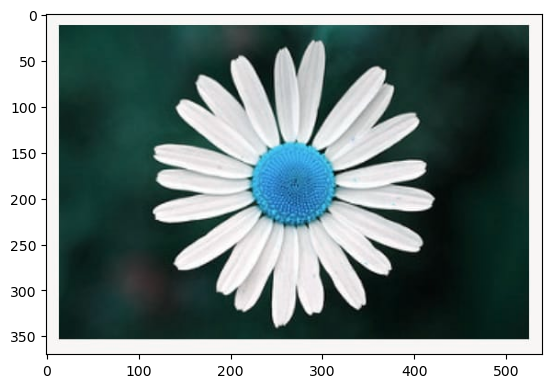

In [3]:
# Display the image
plt.imshow(img)
plt.axis('on') # Hide coordinate axes
plt.show()


In [4]:
# 1. Load the image and convert BGR (OpenCV default) to RGB
#image = cv2.imread("image.jpeg")
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Flatten the image into a 2D array of RGB pixels
pixels = image.reshape((-1, 3))
pixels = np.float32(pixels)  # Convert to float for K-Means accuracy


In [5]:
# 2. Calculate WCSS for the Elbow Method
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(pixels)
    wcss.append(kmeans.inertia_)  # inertia_ holds the WCSS value
    

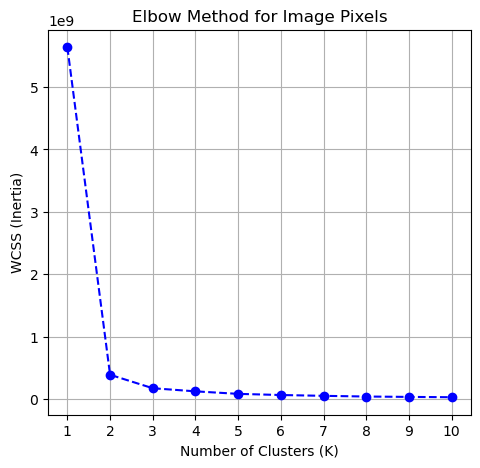

In [6]:
# 3. Plot the WCSS Graph
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Image Pixels')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)


In [9]:
# 4. Generate Segmentation with Optimal K (e.g., K=3 based on your elbow plot)
optimal_k = 100
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
labels = kmeans_final.fit_predict(pixels)

# Replace pixel values with their respective cluster center colors
centers = np.uint8(kmeans_final.cluster_centers_)
segmented_pixels = centers[labels.flatten()]
segmented_image = segmented_pixels.reshape(image.shape)


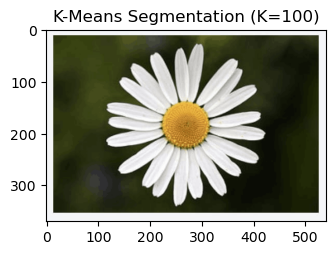

In [10]:
# 5. Plot the Segmented Image side-by-side
plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title(f'K-Means Segmentation (K={optimal_k})')
plt.axis('on')

plt.tight_layout()
plt.show()
